In [ ]:
# Removal of Outliers

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np

In [4]:
# Read the data and split it into three datasets
adata = sc.read_h5ad("../data/frangieh/adata_qc_done")

In [5]:
#Separation into three datasets
adata_control = adata[adata.obs["perturbation_2"] == "Control"].copy()
adata_ifng = adata[adata.obs["perturbation_2"] == "IFNγ"].copy()
adata_coculture = adata[adata.obs["perturbation_2"] == "Co-culture"].copy()

In [6]:
# Normalize the dataset adata_control 
sc.pp.normalize_total(adata_control, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata_control)

In [7]:
# Normalize the dataset adata_ifng 
sc.pp.normalize_total(adata_ifng, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata_ifng)

In [8]:
# Normalize the dataset adata_coculture
sc.pp.normalize_total(adata_coculture, target_sum = 1e4)
sc.pp.log1p(adata_coculture)

In [9]:
#HVG selection
sc.pp.highly_variable_genes(adata_control, n_top_genes=5000)
sc.pp.highly_variable_genes(adata_ifng, n_top_genes=5000)
sc.pp.highly_variable_genes(adata_coculture, n_top_genes=5000)

In [10]:
# Save HVG-filtered datasets
adata_control_hvg = adata_control[:, adata_control.var["highly_variable"]].copy()
adata_ifng_hvg = adata_ifng[:, adata_ifng.var["highly_variable"]].copy()
adata_coculture_hvg = adata_coculture[:, adata_coculture.var["highly_variable"]].copy()

print(adata_control_hvg.shape)
print(adata_ifng_hvg.shape)
print(adata_coculture_hvg.shape)

(49895, 5000)
(74186, 5000)
(67093, 5000)


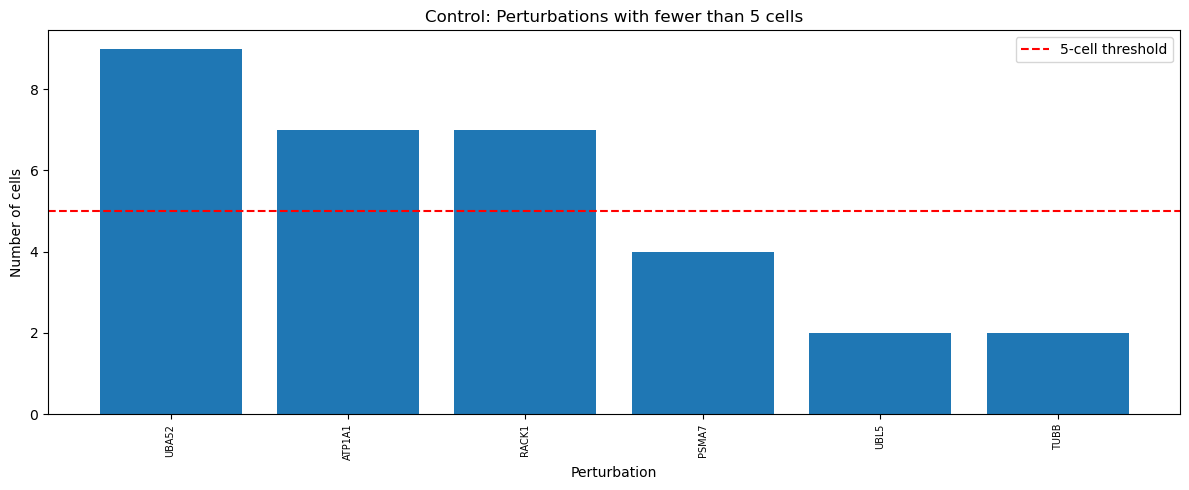

In [43]:
import matplotlib.pyplot as plt

pert_col = "perturbation"

control_counts = (
    adata_control_hvg.obs[pert_col]
    .value_counts()
    .sort_values(ascending=False)
)

# Keep only perturbations with fewer than 10 cells
control_counts_low = control_counts[control_counts < 10]

plt.figure(figsize=(12, 5))
plt.bar(control_counts_low.index, control_counts_low.values)

plt.xticks(rotation=90, fontsize=7)
plt.xlabel("Perturbation")
plt.ylabel("Number of cells")
plt.title("Control: Perturbations with fewer than 5 cells")

# Optional: draw the threshold line
plt.axhline(5, color="red", linestyle="--", label="5-cell threshold")
plt.legend()

plt.tight_layout()
plt.show()

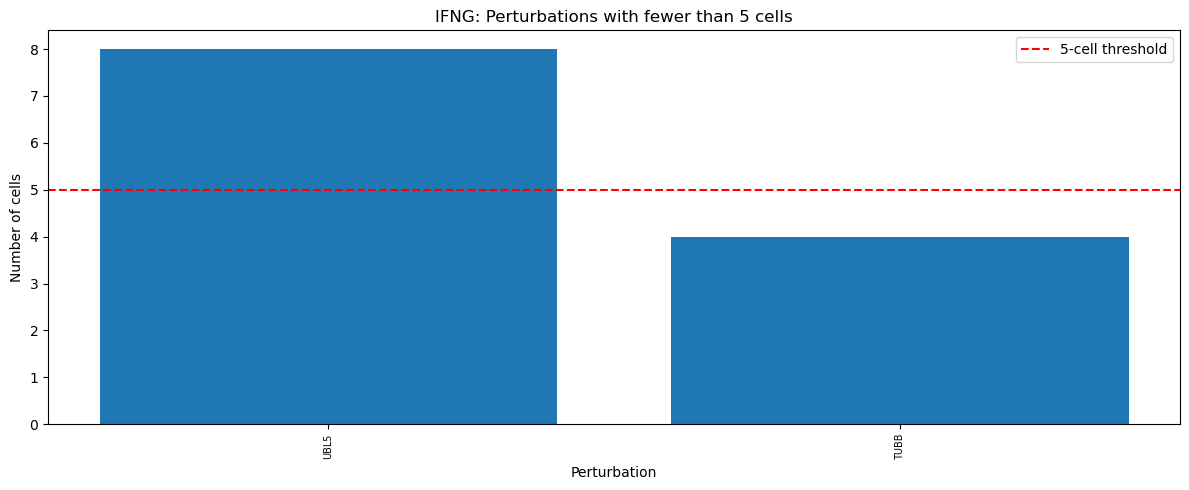

In [44]:
# Plot for IFNG
import matplotlib.pyplot as plt
pert_col = "perturbation"
ifng_counts = (
    adata_ifng_hvg.obs[pert_col]
    .value_counts()
    .sort_values(ascending=False)
)
# Keep only perturbations with fewer than 10 cells
ifng_counts_low = ifng_counts[ifng_counts < 10]
plt.figure(figsize=(12, 5))
plt.bar(ifng_counts_low.index, ifng_counts_low.values)
plt.xticks(rotation=90, fontsize=7)
plt.xlabel("Perturbation")
plt.ylabel("Number of cells")
plt.title("IFNG: Perturbations with fewer than 5 cells")
# Optional: draw the threshold line
plt.axhline(5, color="red", linestyle="--", label="5-cell threshold")
plt.legend()
plt.tight_layout()
plt.show()

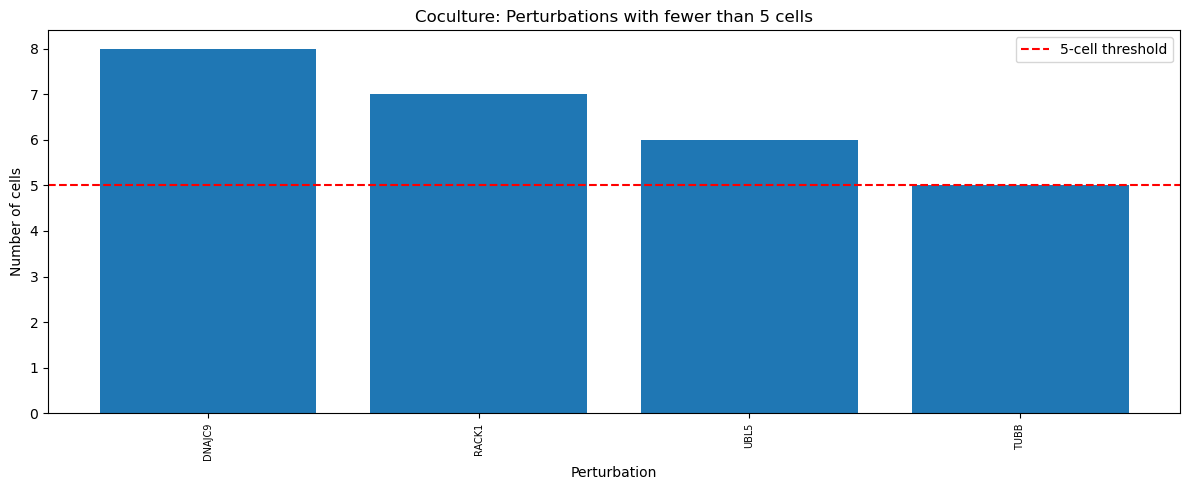

In [45]:
# Plot for IFNG
import matplotlib.pyplot as plt
pert_col = "perturbation"
coculture_counts = (
    adata_coculture_hvg.obs[pert_col]
    .value_counts()
    .sort_values(ascending=False)
)
# Keep only perturbations with fewer than 10 cells
coculture_counts_low = coculture_counts[coculture_counts < 10]
plt.figure(figsize=(12, 5))
plt.bar(coculture_counts_low.index, coculture_counts_low.values)
plt.xticks(rotation=90, fontsize=7)
plt.xlabel("Perturbation")
plt.ylabel("Number of cells")
plt.title("Coculture: Perturbations with fewer than 5 cells")
# Optional: draw the threshold line
plt.axhline(5, color="red", linestyle="--", label="5-cell threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import issparse
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pert_col = "perturbation"
control_name = "control"

min_cells = 10
requested_n_pcs = 50
maximum_k = 10
random_state = 42

# 1. Function to remove perturbations with fewer than 5 cells
def filter_low_count_perturbations(
    adata,
    pert_col="perturbation",
    min_cells=5,
    control_name="control"
):
    """
    Remove perturbations represented by fewer than min_cells cells.

    The control group is checked separately because it is required
    to calculate control-relative perturbation profiles.
    """

    if pert_col not in adata.obs.columns:
        raise KeyError(
            f"Column '{pert_col}' was not found in adata.obs."
        )

    perturbation_labels = adata.obs[pert_col].astype(str)

    cell_counts = perturbation_labels.value_counts()

    if control_name not in cell_counts.index:
        raise ValueError(
            f"Control label '{control_name}' was not found "
            f"in column '{pert_col}'."
        )

    if cell_counts.loc[control_name] < min_cells:
        raise ValueError(
            f"The control group has only "
            f"{cell_counts.loc[control_name]} cells, which is below "
            f"the minimum of {min_cells}."
        )

    valid_perturbations = cell_counts[
        cell_counts >= min_cells
    ].index

    filtered_adata = adata[
        perturbation_labels.isin(valid_perturbations)
    ].copy()

    removed_counts = cell_counts[
        cell_counts < min_cells
    ].sort_values()

    retained_counts = cell_counts[
        cell_counts >= min_cells
    ].sort_values(ascending=False)

    return filtered_adata, retained_counts, removed_counts

In [47]:

# 2. Filter perturbations separately in each condition

adata_control_hvg_filtered, control_retained_counts, control_removed_counts = (
    filter_low_count_perturbations(
        adata_control_hvg,
        pert_col=pert_col,
        min_cells=min_cells,
        control_name=control_name
    )
)

adata_ifng_hvg_filtered, ifng_retained_counts, ifng_removed_counts = (
    filter_low_count_perturbations(
        adata_ifng_hvg,
        pert_col=pert_col,
        min_cells=min_cells,
        control_name=control_name
    )
)

adata_coculture_hvg_filtered, coculture_retained_counts, coculture_removed_counts = (
    filter_low_count_perturbations(
        adata_coculture_hvg,
        pert_col=pert_col,
        min_cells=min_cells,
        control_name=control_name
    )
)

In [48]:
print("Control condition")
print("Before filtering:", adata_control_hvg.shape)
print("After filtering: ", adata_control_hvg_filtered.shape)
print("Removed perturbations:")
print(control_removed_counts)

print("\nIFNγ condition")
print("Before filtering:", adata_ifng_hvg.shape)
print("After filtering: ", adata_ifng_hvg_filtered.shape)
print("Removed perturbations:")
print(ifng_removed_counts)

print("\nCo-culture condition")
print("Before filtering:", adata_coculture_hvg.shape)
print("After filtering: ", adata_coculture_hvg_filtered.shape)
print("Removed perturbations:")
print(coculture_removed_counts)

Control condition
Before filtering: (49895, 5000)
After filtering:  (49864, 5000)
Removed perturbations:
perturbation
UBL5      2
TUBB      2
PSMA7     4
ATP1A1    7
RACK1     7
UBA52     9
Name: count, dtype: int64

IFNγ condition
Before filtering: (74186, 5000)
After filtering:  (74174, 5000)
Removed perturbations:
perturbation
TUBB    4
UBL5    8
Name: count, dtype: int64

Co-culture condition
Before filtering: (67093, 5000)
After filtering:  (67067, 5000)
Removed perturbations:
perturbation
TUBB      5
UBL5      6
RACK1     7
DNAJC9    8
Name: count, dtype: int64


In [49]:

# 3. Calculate perturbation profiles

def calculate_control_relative_profiles(
    adata,
    pert_col="perturbation",
    control_name="control",
    remove_control_profile=True
):
    """
    Calculate perturbation profiles relative to unperturbed controls.

    Rows:
        Genetic perturbations

    Columns:
        Genes

    Values:
        Mean expression of perturbation
        minus
        Mean expression of control cells
    """

    if pert_col not in adata.obs.columns:
        raise KeyError(
            f"Column '{pert_col}' was not found in adata.obs."
        )

    labels = adata.obs[pert_col].astype(str).to_numpy()

    X = adata.X

    if issparse(X):
        X = X.toarray()

    X = np.asarray(X, dtype=np.float32)

    expression_df = pd.DataFrame(
        X,
        index=labels,
        columns=adata.var_names.astype(str)
    )

    # Mean expression for each perturbation
    mean_profiles = expression_df.groupby(level=0).mean()

    if control_name not in mean_profiles.index:
        raise ValueError(
            f"Control label '{control_name}' was not found."
        )

    control_profile = mean_profiles.loc[control_name]

    # Perturbation minus control
    perturbation_profiles = mean_profiles.subtract(
        control_profile,
        axis="columns"
    )

    # The control row is an all-zero reference profile.
    # It is removed before scaling, PCA, and clustering.
    if remove_control_profile:
        perturbation_profiles = perturbation_profiles.drop(
            index=control_name
        )

    return perturbation_profiles, mean_profiles

In [50]:
profiles_control, mean_profiles_control = (
    calculate_control_relative_profiles(
        adata_control_hvg_filtered,
        pert_col=pert_col,
        control_name=control_name,
        remove_control_profile=True
    )
)

profiles_ifng, mean_profiles_ifng = (
    calculate_control_relative_profiles(
        adata_ifng_hvg_filtered,
        pert_col=pert_col,
        control_name=control_name,
        remove_control_profile=True
    )
)

profiles_coculture, mean_profiles_coculture = (
    calculate_control_relative_profiles(
        adata_coculture_hvg_filtered,
        pert_col=pert_col,
        control_name=control_name,
        remove_control_profile=True
    )
)

In [51]:
print("Control perturbation profiles:", profiles_control.shape)
print("IFNγ perturbation profiles:", profiles_ifng.shape)
print("Co-culture perturbation profiles:", profiles_coculture.shape)

print("\nFirst control-condition profiles:")
print(profiles_control.iloc[:5, :5])

Control perturbation profiles: (242, 5000)
IFNγ perturbation profiles: (246, 5000)
Co-culture perturbation profiles: (244, 5000)

First control-condition profiles:
gene_symbol     AADAC      AASS     AATBC      AATK     ABCA1
A2M         -0.002260 -0.009561 -0.000236 -0.000304  0.011157
ACSL3        0.001650 -0.019698 -0.000236 -0.002325  0.025140
ACTA2       -0.002260  0.000578 -0.000236  0.006617  0.013927
AEBP1        0.000908 -0.005341  0.001160  0.001555 -0.015150
AGA          0.000950 -0.005413 -0.000236 -0.002325  0.008666


In [52]:

# 4. Scale and calculate PCA

def scale_and_compute_pca(
    profiles,
    requested_n_pcs=50,
    random_state=42
):
    """
    Scale every gene across perturbation profiles and calculate PCA.
    """

    if profiles.shape[0] < 3:
        raise ValueError(
            "At least three perturbation profiles are required."
        )

    # Scale genes:
    # mean = 0 and standard deviation = 1
    scaler = StandardScaler()

    scaled_profiles = scaler.fit_transform(
        profiles.to_numpy()
    )

    # PCA cannot have more components than:
    # min(number of samples, number of variables)
    actual_n_pcs = min(
        requested_n_pcs,
        scaled_profiles.shape[0],
        scaled_profiles.shape[1]
    )

    pca_model = PCA(
        n_components=actual_n_pcs,
        random_state=random_state
    )

    pca_coordinates = pca_model.fit_transform(
        scaled_profiles
    )

    return {
        "scaled": scaled_profiles,
        "pca": pca_coordinates,
        "scaler": scaler,
        "pca_model": pca_model,
        "n_pcs": actual_n_pcs
    }

In [53]:
control_results = scale_and_compute_pca(
    profiles_control,
    requested_n_pcs=requested_n_pcs,
    random_state=random_state
)

ifng_results = scale_and_compute_pca(
    profiles_ifng,
    requested_n_pcs=requested_n_pcs,
    random_state=random_state
)

coculture_results = scale_and_compute_pca(
    profiles_coculture,
    requested_n_pcs=requested_n_pcs,
    random_state=random_state
)

In [54]:
control_scaled = control_results["scaled"]
ifng_scaled = ifng_results["scaled"]
coculture_scaled = coculture_results["scaled"]

control_pca = control_results["pca"]
ifng_pca = ifng_results["pca"]
coculture_pca = coculture_results["pca"]

In [55]:
print("Control scaled:", control_scaled.shape)
print("Control PCA:", control_pca.shape)

print("IFNγ scaled:", ifng_scaled.shape)
print("IFNγ PCA:", ifng_pca.shape)

print("Co-culture scaled:", coculture_scaled.shape)
print("Co-culture PCA:", coculture_pca.shape)

Control scaled: (242, 5000)
Control PCA: (242, 50)
IFNγ scaled: (246, 5000)
IFNγ PCA: (246, 50)
Co-culture scaled: (244, 5000)
Co-culture PCA: (244, 50)


In [56]:
print(
    "Control variance explained by PCA:",
    control_results["pca_model"]
    .explained_variance_ratio_
    .sum()
)

print(
    "IFNγ variance explained by PCA:",
    ifng_results["pca_model"]
    .explained_variance_ratio_
    .sum()
)

print(
    "Co-culture variance explained by PCA:",
    coculture_results["pca_model"]
    .explained_variance_ratio_
    .sum()
)

Control variance explained by PCA: 0.48078835
IFNγ variance explained by PCA: 0.49101394
Co-culture variance explained by PCA: 0.51949245


In [57]:

# 5. Calculate elbow and silhouette scores


def evaluate_kmeans_clusters(
    pca_coordinates,
    condition_name,
    maximum_k=20,
    n_pcs_for_clustering=30,
    random_state=42,
    n_init=20
):
    """
    Evaluate K-means using elbow inertia and silhouette score.
    """

    # Use up to the first 50 PCs 
    actual_pcs_for_clustering = min(
        n_pcs_for_clustering,
        pca_coordinates.shape[1]
    )

    X = pca_coordinates[
        :,
        :actual_pcs_for_clustering
    ]

    # Silhouette requires:
    # 2 <= k <= number of samples - 1
    largest_valid_k = min(
        maximum_k,
        X.shape[0] - 1
    )

    if largest_valid_k < 2:
        raise ValueError(
            f"Not enough perturbations in {condition_name} "
            f"to evaluate K-means."
        )

    k_values = list(range(2, largest_valid_k + 1))

    inertia_values = []
    silhouette_values = []

    for k in k_values:

        kmeans = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=n_init
        )

        cluster_labels = kmeans.fit_predict(X)

        inertia_values.append(
            kmeans.inertia_
        )

        silhouette_values.append(
            silhouette_score(
                X,
                cluster_labels
            )
        )

    results_table = pd.DataFrame({
        "k": k_values,
        "inertia": inertia_values,
        "silhouette_score": silhouette_values
    })

    best_k_silhouette = int(
        results_table.loc[
            results_table["silhouette_score"].idxmax(),
            "k"
        ]
    )

    print(f"\n{condition_name}")
    print(
        f"PCs used for clustering: "
        f"{actual_pcs_for_clustering}"
    )
    print(results_table)
    print(
        f"Highest silhouette score: k = "
        f"{best_k_silhouette}"
    )

    return results_table, best_k_silhouette

In [58]:
control_k_results, control_best_k = evaluate_kmeans_clusters(
    control_pca,
    condition_name="Control",
    maximum_k=maximum_k,
    n_pcs_for_clustering=50,
    random_state=random_state,
    n_init=20
)

ifng_k_results, ifng_best_k = evaluate_kmeans_clusters(
    ifng_pca,
    condition_name="IFNγ",
    maximum_k=maximum_k,
    n_pcs_for_clustering=50,
    random_state=random_state,
    n_init=20
)

coculture_k_results, coculture_best_k = evaluate_kmeans_clusters(
    coculture_pca,
    condition_name="Co-culture",
    maximum_k=maximum_k,
    n_pcs_for_clustering=50,
    random_state=random_state,
    n_init=20
)


Control
PCs used for clustering: 50
    k       inertia  silhouette_score
0   2  550024.75000          0.715071
1   3  528319.81250          0.577424
2   4  507482.28125          0.666895
3   5  493289.90625          0.559937
4   6  471849.25000          0.563592
5   7  453530.21875          0.566784
6   8  434508.90625          0.643424
7   9  416289.84375          0.648537
8  10  399527.12500          0.552268
Highest silhouette score: k = 2

IFNγ
PCs used for clustering: 50
    k       inertia  silhouette_score
0   2  577024.56250          0.689026
1   3  554847.37500          0.676064
2   4  532501.87500          0.676970
3   5  508983.43750          0.678412
4   6  485684.18750          0.679727
5   7  466462.59375          0.657629
6   8  449978.18750          0.377837
7   9  426870.65625          0.384607
8  10  408556.46875          0.390356
Highest silhouette score: k = 2

Co-culture
PCs used for clustering: 50
    k       inertia  silhouette_score
0   2  605775.12500        

In [59]:

# 6. Plot elbow and silhouette results

def plot_kmeans_evaluation(
    results_table,
    condition_name
):
    """
    Plot elbow and silhouette results in separate figures.
    """

    # Elbow plot
    plt.figure(figsize=(7, 5))

    plt.plot(
        results_table["k"],
        results_table["inertia"],
        marker="o"
    )

    plt.xticks(results_table["k"])
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title(
        f"Elbow method – {condition_name}"
    )

    plt.tight_layout()
    plt.show()

    # Silhouette plot
    plt.figure(figsize=(7, 5))

    plt.plot(
        results_table["k"],
        results_table["silhouette_score"],
        marker="o"
    )

    best_row = results_table.loc[
        results_table["silhouette_score"].idxmax()
    ]

    plt.axvline(
        best_row["k"],
        linestyle="--",
        label=(
            f"Highest silhouette: "
            f"k = {int(best_row['k'])}"
        )
    )

    plt.xticks(results_table["k"])
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.title(
        f"Silhouette analysis – {condition_name}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

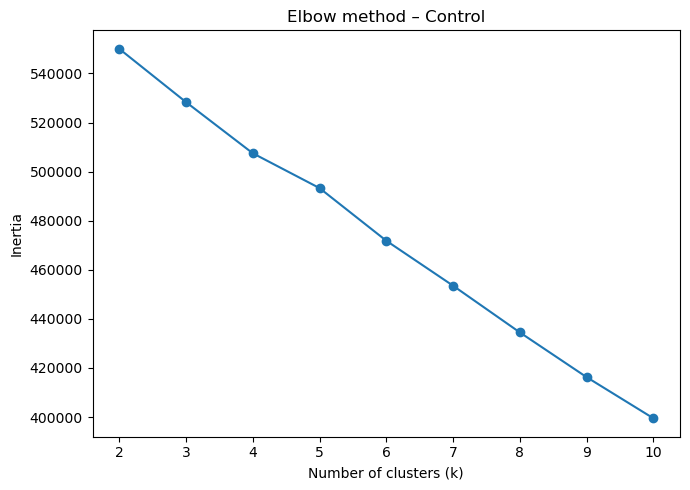

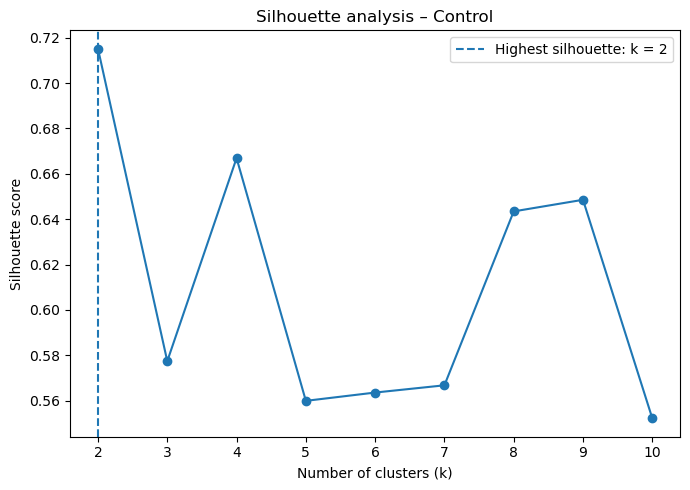

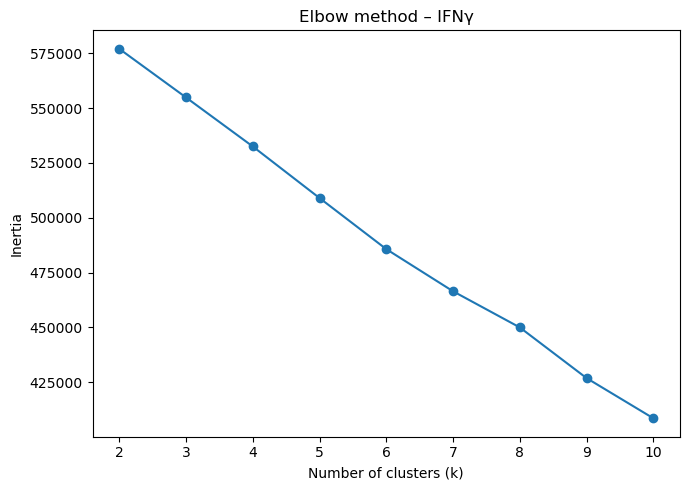

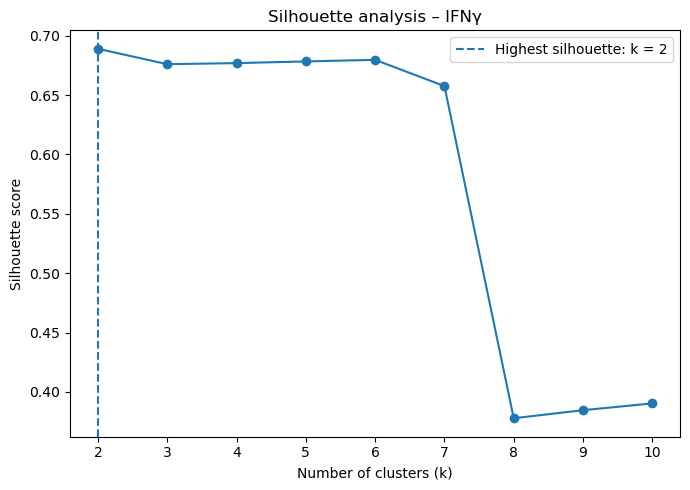

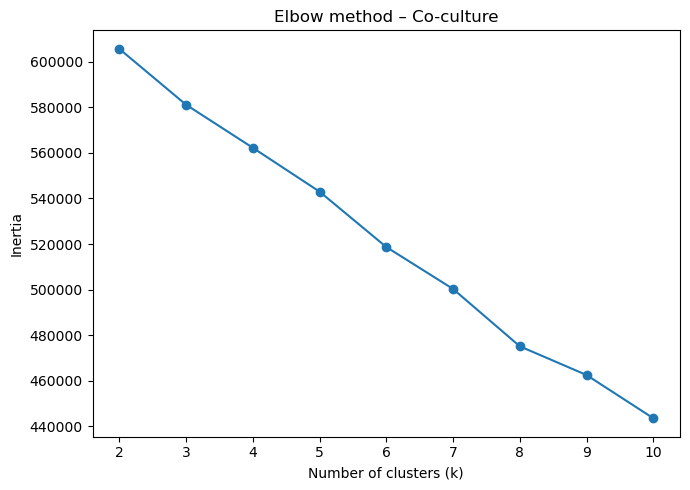

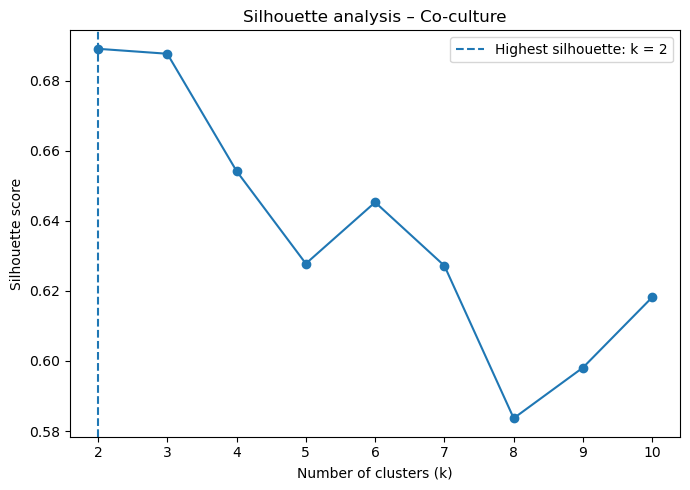

In [60]:
plot_kmeans_evaluation(
    control_k_results,
    "Control"
)

plot_kmeans_evaluation(
    ifng_k_results,
    "IFNγ"
)

plot_kmeans_evaluation(
    coculture_k_results,
    "Co-culture"
)

In [74]:
from sklearn.cluster import KMeans

# Number of clusters
k = 2
g = 2
c = 2
# Number of PCs used for clustering
n_pcs = 50


# Control

kmeans_control = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=20
)

control_clusters = kmeans_control.fit_predict(
    control_pca[:, :n_pcs]
)


# IFNγ

kmeans_ifng = KMeans(
    n_clusters=g,
    random_state=42,
    n_init=20
)

ifng_clusters = kmeans_ifng.fit_predict(
    ifng_pca[:, :n_pcs]
)


# Co-culture

kmeans_coculture = KMeans(
    n_clusters=c,
    random_state=42,
    n_init=20
)

coculture_clusters = kmeans_coculture.fit_predict(
    coculture_pca[:, :n_pcs]
)

In [75]:
import matplotlib.pyplot as plt
import numpy as np

def plot_kmeans_pca(
    pca,
    clusters,
    perturbation_names,
    title
):
    plt.figure(figsize=(8, 6))

    unique_clusters = np.sort(np.unique(clusters))

    # Automatically generate one color per cluster
    cmap = plt.get_cmap("tab10")

    for i, cluster in enumerate(unique_clusters):

        idx = clusters == cluster

        plt.scatter(
            pca[idx, 0],
            pca[idx, 1],
            s=80,
            color=cmap(i),
            edgecolor="black",
            label=f"Cluster {cluster}"
        )

    # Add perturbation labels
    for i, pert in enumerate(perturbation_names):
        plt.text(
            pca[i, 0] + 0.05,
            pca[i, 1] + 0.05,
            str(pert),
            fontsize=8
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)

    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    plt.tight_layout()
    plt.show()

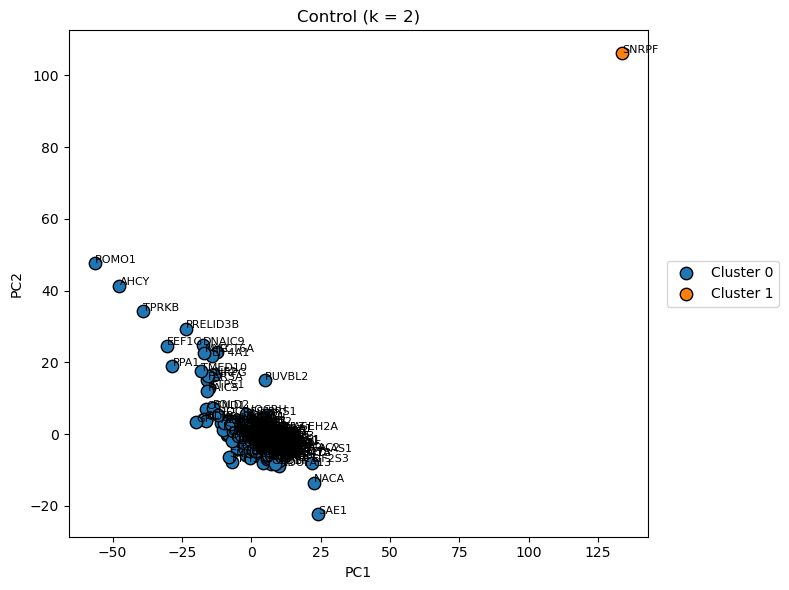

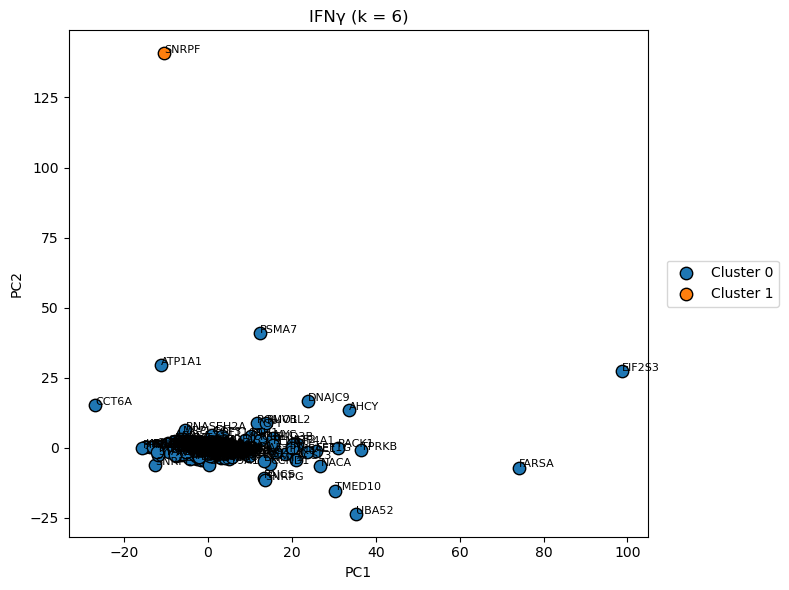

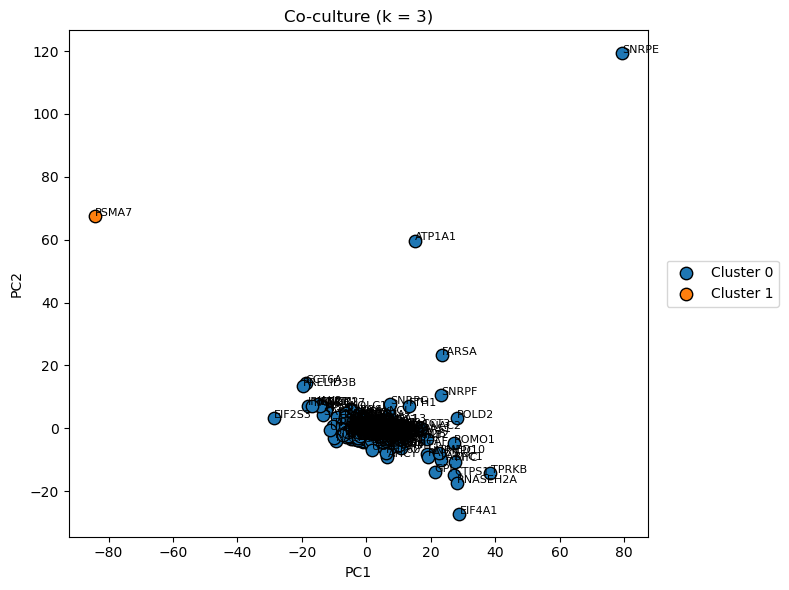

In [76]:
plot_kmeans_pca(
    control_pca,
    control_clusters,
    profiles_control.index,
    "Control (k = 2)"
)

plot_kmeans_pca(
    ifng_pca,
    ifng_clusters,
    profiles_ifng.index,
    "IFNγ (k = 6)"
)

plot_kmeans_pca(
    coculture_pca,
    coculture_clusters,
    profiles_coculture.index,
    "Co-culture (k = 3)"
)